### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from IPython.display import display
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [92]:
data = pd.read_csv('/content/coupons.csv')

In [93]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [94]:
data.info()

missing_summary = (
    data.isna()
        .sum()
        .to_frame("missing_count")
        .assign(missing_pct=lambda x: (x["missing_count"] / len(data) * 100).round(2))
        .query("missing_count > 0")
        .sort_values("missing_count", ascending=False)
)

duplicate_rows = data.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_rows}")
display(missing_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,missing_count,missing_pct
car,12576,99.15
CoffeeHouse,217,1.71
Restaurant20To50,189,1.49
CarryAway,151,1.19
RestaurantLessThan20,130,1.02
Bar,107,0.84


3. Decide what to do about your missing data -- drop, replace, other...

In [95]:
clean = data.drop(columns=["car"]).dropna().copy()
clean = clean.rename(columns={"passanger": "passenger"})

rows_removed = len(data) - len(clean)
pct_removed = rows_removed / len(data) * 100

print(f"Original shape: {data.shape}")
print(f"Cleaned shape : {clean.shape}")
print(f"Rows removed  : {rows_removed} ({pct_removed:.2f}% of the data)")
print(f"Remaining missing values: {clean.isna().sum().sum()}")

display(clean.head())

Original shape: (12684, 26)
Cleaned shape : (12079, 25)
Rows removed  : 605 (4.77% of the data)
Remaining missing values: 0


,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [96]:
overall_acceptance = clean["Y"].mean()

acceptance_summary = pd.DataFrame({
    "metric": ["Overall acceptance rate", "Overall rejection rate"],
    "value": [overall_acceptance, 1 - overall_acceptance]
})
acceptance_summary["value"] = acceptance_summary["value"].map(lambda x: f"{x:.2%}")

display(acceptance_summary)

,metric,value
0,Overall acceptance rate,56.93%
1,Overall rejection rate,43.07%


5. Use a bar plot to visualize the `coupon` column.

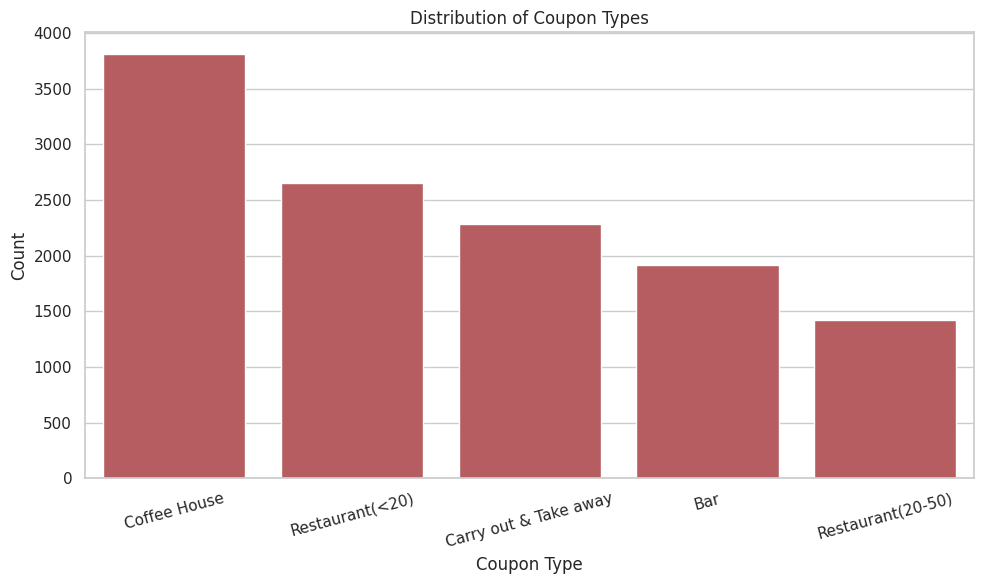

In [97]:
coupon_counts = clean["coupon"].value_counts().reset_index()
coupon_counts.columns = ["coupon", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=coupon_counts, x="coupon", y="count", color="C3")
plt.title("Distribution of Coupon Types")
plt.xlabel("Coupon Type")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

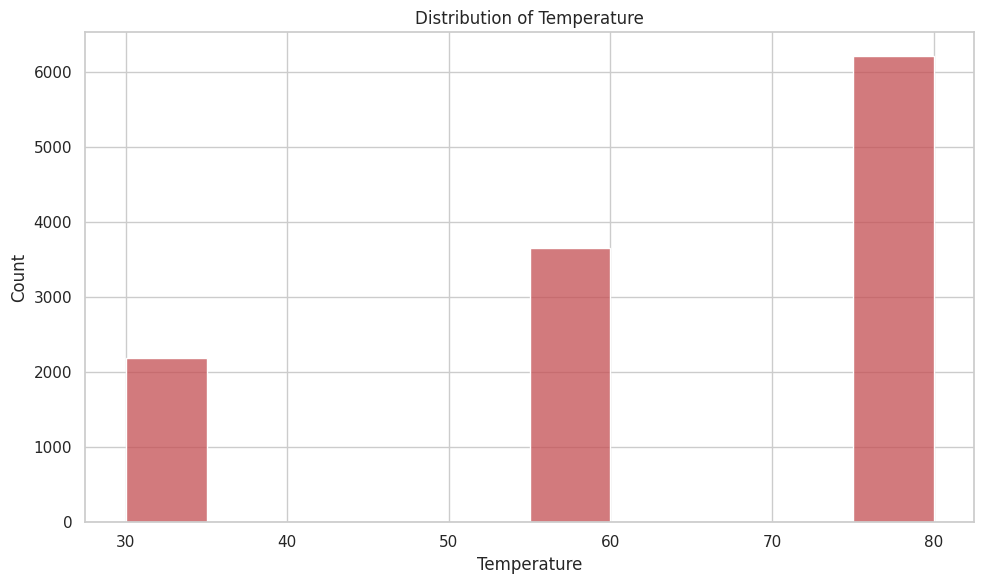

In [98]:
plt.figure(figsize=(10, 6))
sns.histplot(data=clean, x="temperature", bins=10, color="C3")
plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

,coupon,acceptance_rate
0,Carry out & Take away,0.737719
1,Restaurant(<20),0.709009
2,Coffee House,0.496331
3,Restaurant(20-50),0.446013
4,Bar,0.411918


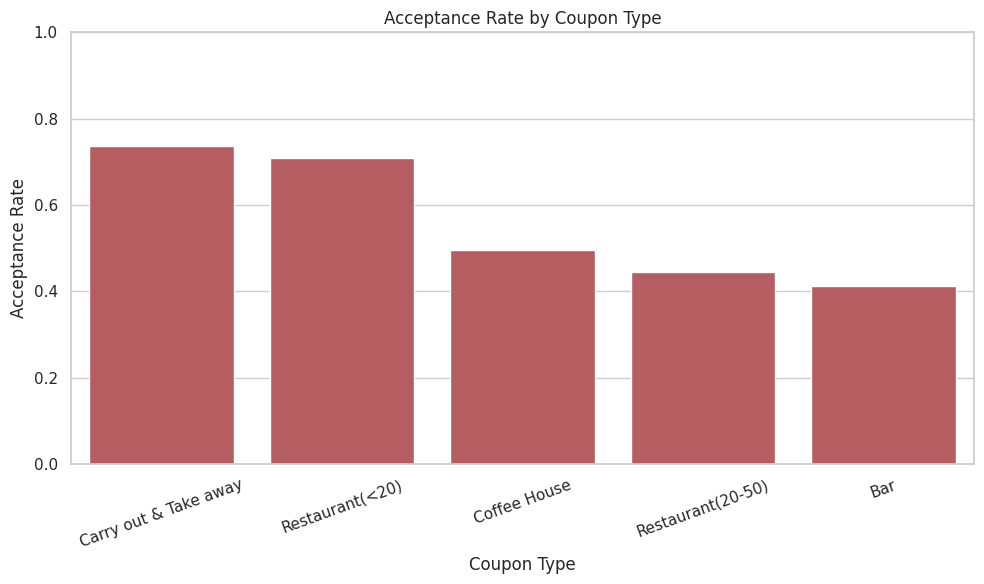

In [99]:
acceptance_by_coupon = (
    clean.groupby("coupon")["Y"]
         .mean()
         .sort_values(ascending=False)
         .reset_index(name="acceptance_rate")
)

display(acceptance_by_coupon)

plt.figure(figsize=(10, 6))
sns.barplot(data=acceptance_by_coupon, x="coupon", y="acceptance_rate", color="C3")
plt.title("Acceptance Rate by Coupon Type")
plt.xlabel("Coupon Type")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

,time,acceptance_rate
0,7AM,0.503968
1,10AM,0.607970
2,2PM,0.660752
3,6PM,0.582846
4,10PM,0.515502


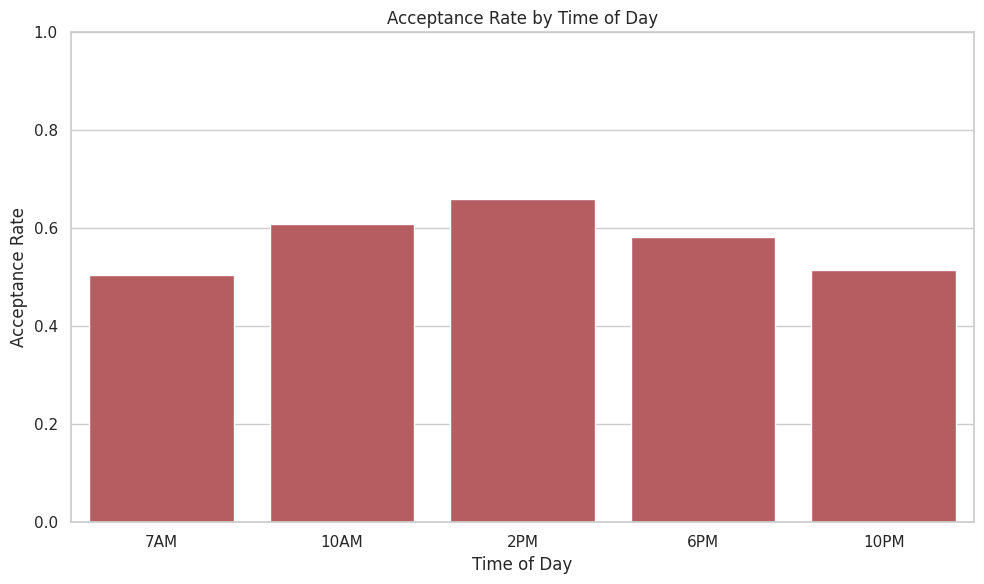

In [101]:
# Coupon Acceptance Rate by Time of Day

time_order = ["7AM", "10AM", "2PM", "6PM", "10PM"]

acceptance_by_time = (
    clean.groupby("time")["Y"]
         .mean()
         .reindex(time_order)
         .reset_index(name="acceptance_rate")
)

display(acceptance_by_time)

plt.figure(figsize=(10, 6))
sns.barplot(data=acceptance_by_time, x="time", y="acceptance_rate", order=time_order, color="C3")
plt.title("Acceptance Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Acceptance Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [102]:
bar_df = clean[clean["coupon"] == "Bar"].copy()

print(f"Bar coupon rows: {len(bar_df):,}")
display(bar_df.head())

Bar coupon rows: 1,913


,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,0,Bachelors degree,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,0,Some college - no degree,Student,$12500 - $24999,never,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,0,Some college - no degree,Student,$12500 - $24999,never,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [103]:
bar_acceptance_rate = bar_df["Y"].mean()
print(f"Bar coupon acceptance rate: {bar_acceptance_rate:.2%}")

Bar coupon acceptance rate: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


,group,acceptance_rate,count
0,Bar visits <= 3/month,0.372674,1720
1,Bar visits > 3/month,0.761658,193


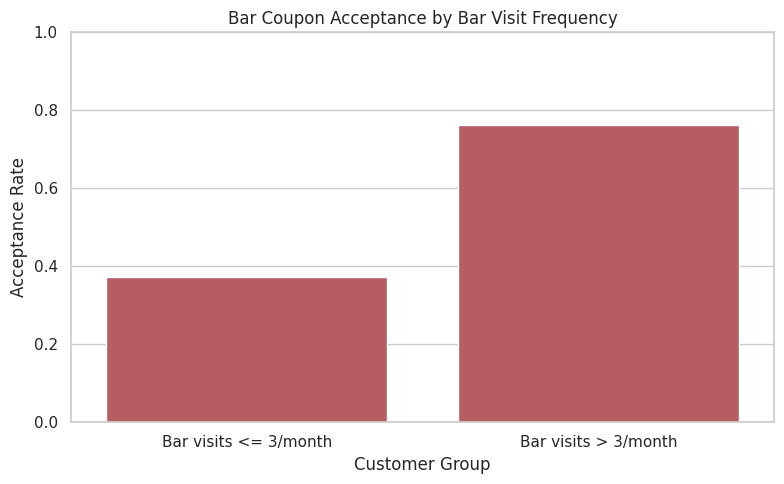

In [104]:
# This directly answers one of the key bar-coupon comparison questions in the assignment.

bar_3_or_fewer = bar_df[bar_df["Bar"].isin(["never", "less1", "1~3"])]
bar_more_than_3 = bar_df[bar_df["Bar"].isin(["4~8", "gt8"])]

bar_visit_comparison = pd.DataFrame({
    "group": ["Bar visits <= 3/month", "Bar visits > 3/month"],
    "acceptance_rate": [bar_3_or_fewer["Y"].mean(), bar_more_than_3["Y"].mean()],
    "count": [len(bar_3_or_fewer), len(bar_more_than_3)]
})

display(bar_visit_comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=bar_visit_comparison, x="group", y="acceptance_rate", color="C3")
plt.title("Bar Coupon Acceptance by Bar Visit Frequency")
plt.xlabel("Customer Group")
plt.ylabel("Acceptance Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [105]:
# This tests whether older, more frequent bar-goers accept bar coupons at a different rate than everyone else.

older_frequent_bar_goers = bar_df[
    bar_df["Bar"].isin(["1~3", "4~8", "gt8"]) &
    bar_df["age"].isin(["26", "31", "36", "41", "46", "50plus"])
]

all_others_q4 = bar_df.drop(older_frequent_bar_goers.index)

q4_comparison = pd.DataFrame({
    "group": ["Go to bars >1/month and age >25", "All others"],
    "acceptance_rate": [older_frequent_bar_goers["Y"].mean(), all_others_q4["Y"].mean()],
    "count": [len(older_frequent_bar_goers), len(all_others_q4)]
})

display(q4_comparison)

,group,acceptance_rate,count
0,Go to bars >1/month and age >25,0.689826,403
1,All others,0.337748,1510


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [106]:


q5_group = bar_df[
    bar_df["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (bar_df["passenger"] != "Kid(s)") &
    (bar_df["occupation"] != "Farming Fishing & Forestry")
]

all_others_q5 = bar_df.drop(q5_group.index)

q5_comparison = pd.DataFrame({
    "group": [
        "Frequent bar-goers + no kid passengers + occupation not F/F/F",
        "All others"
    ],
    "acceptance_rate": [q5_group["Y"].mean(), all_others_q5["Y"].mean()],
    "count": [len(q5_group), len(all_others_q5)]
})

display(q5_comparison)

,group,acceptance_rate,count
0,Frequent bar-goers + no kid passengers + occup...,0.709434,530
1,All others,0.297903,1383


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [108]:
condition_1 = (
    bar_df["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (bar_df["passenger"] != "Kid(s)") &
    (bar_df["maritalStatus"] != "Widowed")
)

condition_2 = (
    bar_df["Bar"].isin(["1~3", "4~8", "gt8"]) &
    bar_df["age"].isin(["below21", "21", "26"])
)

condition_3 = (
    bar_df["RestaurantLessThan20"].isin(["4~8", "gt8"]) &
    bar_df["income"].isin([
        "Less than $12500",
        "$12500 - $24999",
        "$25000 - $37499",
        "$37500 - $49999"
    ])
)

q6_group = bar_df[condition_1 | condition_2 | condition_3]
all_others_q6 = bar_df.drop(q6_group.index)

q6_comparison = pd.DataFrame({
    "group": ["Prompt target group (OR rule)", "All others"],
    "acceptance_rate": [q6_group["Y"].mean(), all_others_q6["Y"].mean()],
    "count": [len(q6_group), len(all_others_q6)]
})

display(q6_comparison)

,group,acceptance_rate,count
0,Prompt target group (OR rule),0.587131,746
1,All others,0.299914,1167


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
Drivers who accepted bar coupons were more likely to already have lifestyles and routines that aligned with going to bars. In particular, acceptance appears higher among people who visit bars more than once a month, are in more flexible social situations such as traveling with friends or partners rather than children, and are not constrained by urgent trip purposes. Acceptance also seems higher among younger drivers and among drivers whose spending patterns suggest they are more responsive to lower-cost dining and promotional offers. Overall, I hypothesize that bar coupon acceptance is strongest when the offer matches both the driver’s usual habits and the immediate social and travel context.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [109]:
# This tests whether frequent bar attendance is statistically associated with bar coupon acceptance.

bar_freq_table = pd.crosstab(
    bar_df["Bar"].isin(["4~8", "gt8"]),
    bar_df["Y"]
)

chi2_bar, p_bar, dof_bar, expected_bar = chi2_contingency(bar_freq_table)

print("Contingency table: frequent bar visits (>3/month) vs acceptance")
display(bar_freq_table)

print(f"Chi-square statistic: {chi2_bar:.3f}")
print(f"p-value: {p_bar:.3e}")

Contingency table: frequent bar visits (>3/month) vs acceptance


Y,0,1
Bar,,
False,1079,641
True,46,147


Chi-square statistic: 106.789
p-value: 4.952e-25


In [110]:
#Coffee House subset and its overall acceptance rate

coffee_df = clean[clean["coupon"] == "Coffee House"].copy()

coffee_acceptance_rate = coffee_df["Y"].mean()

print(f"Coffee House rows: {len(coffee_df):,}")
print(f"Coffee House acceptance rate: {coffee_acceptance_rate:.2%}")

Coffee House rows: 3,816
Coffee House acceptance rate: 49.63%


In [112]:
# Investigate which characteristics are associated with Coffee House coupon acceptance

coffee_acceptance_by_frequency = (
    coffee_df.groupby("CoffeeHouse")["Y"]
             .mean()
             .reindex(["never", "less1", "1~3", "4~8", "gt8"])
             .reset_index(name="acceptance_rate")
)

coffee_acceptance_by_expiration = (
    coffee_df.groupby("expiration")["Y"]
             .mean()
             .sort_values(ascending=False)
             .reset_index(name="acceptance_rate")
)

coffee_acceptance_by_destination = (
    coffee_df.groupby("destination")["Y"]
             .mean()
             .sort_values(ascending=False)
             .reset_index(name="acceptance_rate")
)

coffee_acceptance_by_passenger = (
    coffee_df.groupby("passenger")["Y"]
             .mean()
             .sort_values(ascending=False)
             .reset_index(name="acceptance_rate")
)

print("Acceptance rate by CoffeeHouse visit frequency")
display(coffee_acceptance_by_frequency)

print("Acceptance rate by coupon expiration")
display(coffee_acceptance_by_expiration)

print("Acceptance rate by destination")
display(coffee_acceptance_by_destination)

print("Acceptance rate by passenger")
display(coffee_acceptance_by_passenger)

Acceptance rate by CoffeeHouse visit frequency


,CoffeeHouse,acceptance_rate
0,never,0.175223
1,less1,0.480989
2,1~3,0.647694
3,4~8,0.682446
4,gt8,0.657895


Acceptance rate by coupon expiration


,expiration,acceptance_rate
0,1d,0.580626
1,2h,0.429110


Acceptance rate by destination


,destination,acceptance_rate
0,No Urgent Place,0.578178
1,Work,0.440000
2,Home,0.362613


Acceptance rate by passenger


,passenger,acceptance_rate
0,Friend(s),0.597447
1,Partner,0.567010
2,Kid(s),0.471503
3,Alone,0.433936


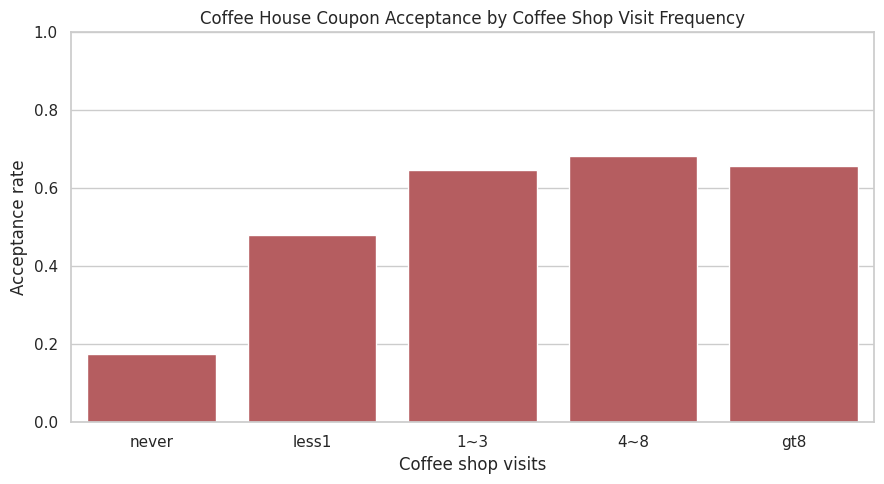

In [113]:
# Coffee House Cupon Acceptance by Coffee Shop Visit Frequency

plt.figure(figsize=(9, 5))
sns.barplot(data=coffee_acceptance_by_frequency, x="CoffeeHouse", y="acceptance_rate",
            order=["never", "less1", "1~3", "4~8", "gt8"], color="C3")
plt.title("Coffee House Coupon Acceptance by Coffee Shop Visit Frequency")
plt.xlabel("Coffee shop visits")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


,destination,acceptance_rate
0,No Urgent Place,0.634003
1,Home,0.508266
2,Work,0.503968


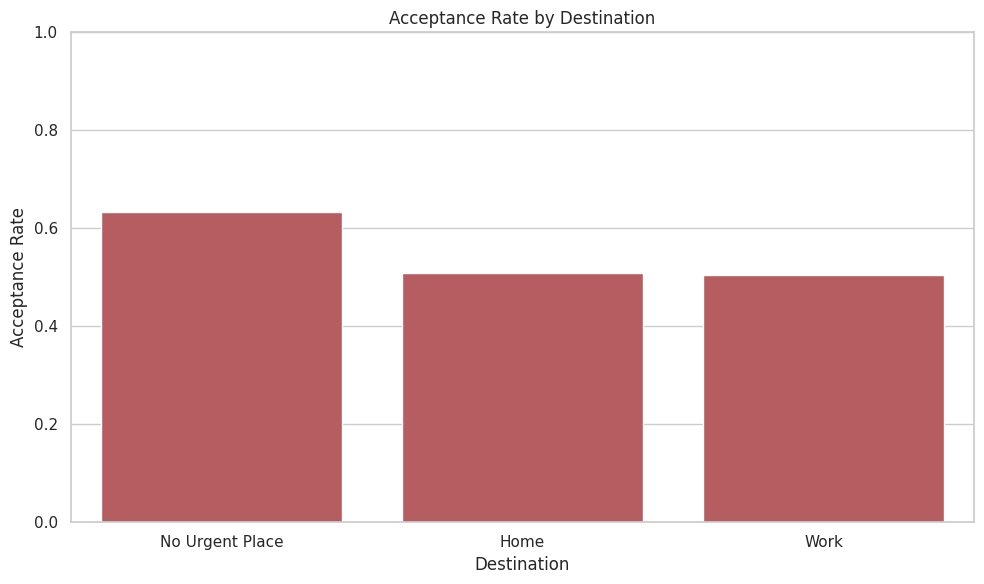

In [114]:
# Coffee House Coupon Acceptance by Desitination

acceptance_by_destination = (
    clean.groupby("destination")["Y"]
         .mean()
         .sort_values(ascending=False)
         .reset_index(name="acceptance_rate")
)

display(acceptance_by_destination)

plt.figure(figsize=(10, 6))
sns.barplot(data=acceptance_by_destination, x="destination", y="acceptance_rate", color="C3")
plt.title("Acceptance Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Acceptance Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()